# Kepler exoplanet classification — Notebook 03

**Deep learning models: MLP, ResNet, and FT-Transformer**

Author: Atilla Ahmed

---

## Abstract

This notebook implements and evaluates three modern deep learning architectures for tabular data on the Kepler classification task: a Multi-Layer Perceptron (MLP), a residual-connection tabular network (ResNet-Tabular), and a Feature Tokenizer + Transformer (FT-Transformer).
Models are trained primarily on the leak-free feature configuration defined in Notebook 01 and benchmarked against the XGBoost baseline established in Notebook 02. A soft-voting ensemble combines the three architectures for the final result.

## Table of contents

1. [Data loading and training setup](#1-data-loading-and-training-setup)
2. [Multi-Layer Perceptron](#2-multi-layer-perceptron)
3. [Residual Tabular Network](#3-residual-tabular-network)
4. [Feature Tokenizer Transformer](#4-feature-tokenizer-transformer)
5. [Model ensemble](#5-model-ensemble)
6. [Summary](#6-summary)

## 1. Data loading and training setup

We load the processed splits from Notebook 01, prepare PyTorch tensors on the GPU, and define a single training function that will be used consistently for all three deep learning models.

### 1.1. Imports and configuration

In [1]:
import json
import warnings
from pathlib import Path
from typing import Callable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_SEED = 42
BATCH_SIZE = 256
MAX_EPOCHS = 100
PATIENCE = 15
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5

PROCESSED_PATH = Path("../data/processed")
MODELS_PATH = Path("../models/dl")
MODELS_PATH.mkdir(parents=True, exist_ok=True)

int_to_class = {0: "CONFIRMED", 1: "CANDIDATE", 2: "FALSE POSITIVE"}
class_order = ["CONFIRMED", "CANDIDATE", "FALSE POSITIVE"]

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

print("Setup complete")

Setup complete


### 1.2. GPU configuration

We detect the available compute device and prepare a global `device` variable used consistently across all model definitions and training loops.

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU:    {torch.cuda.get_device_name(0)}")

Device: cuda
GPU:    NVIDIA GeForce RTX 4050 Laptop GPU


### 1.3. Load processed data

We read the three parquet splits, load the feature-set definitions, and apply the same `StandardScaler` fit on training data used in Notebook 02. Since PyTorch models cannot participate in an `sklearn.pipeline.Pipeline` cleanly, we scale the features explicitly before creating tensors.

In [3]:
train_df = pd.read_parquet(PROCESSED_PATH / "train.parquet")
val_df = pd.read_parquet(PROCESSED_PATH / "val.parquet")
test_df = pd.read_parquet(PROCESSED_PATH / "test.parquet")

with open(PROCESSED_PATH / "feature_sets.json", "r") as f:
    feature_sets = json.load(f)

def split_features_target(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series]:
    return df.drop(columns=["target"]), df["target"]

X_train, y_train = split_features_target(train_df)
X_val, y_val = split_features_target(val_df)
X_test, y_test = split_features_target(test_df)

feature_sets_effective = {
    "setup_leaky": [c for c in feature_sets["setup_a_leaky"] if c in X_train.columns],
    "setup_leak_free": [c for c in feature_sets["setup_c_leak_free"] if c in X_train.columns],
}

print(f"Train: {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test: {X_test.shape}")
for name, features in feature_sets_effective.items():
    print(f" {name}: {len(features)} features")

Train: (6694, 101)
Validation: (1435, 101)
Test: (1435, 101)
 setup_leaky: 55 features
 setup_leak_free: 51 features


### 1.4. Prepare tensors and DataLoaders

We scale the features with `StandardScaler` fit on the training set only, convert everything to PyTorch tensors on the GPU, and wrap them in `DataLoader` objects for batched training.

In [4]:
def prepare_dataloaders(
    features: list[str],
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_val: pd.DataFrame,
    y_val: pd.Series,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    batch_size: int = BATCH_SIZE,
) -> tuple[DataLoader, DataLoader, DataLoader, StandardScaler]:
    """Scale features and build train/val/test DataLoaders.

    Fits StandardScaler on train only, applies to val and test.
    Returns dataloaders and the fitted scaler for future use.
    """
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_train[features])
    X_va = scaler.transform(X_val[features])
    X_te = scaler.transform(X_test[features])

    train_ds = TensorDataset(
        torch.tensor(X_tr, dtype=torch.float32),
        torch.tensor(y_train.values, dtype=torch.long),
    )
    val_ds = TensorDataset(
        torch.tensor(X_va, dtype=torch.float32),
        torch.tensor(y_val.values, dtype=torch.long),
    )
    test_ds = TensorDataset(
        torch.tensor(X_te, dtype=torch.float32),
        torch.tensor(y_test.values, dtype=torch.long),
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader, scaler


features_c = feature_sets_effective["setup_leak_free"]

train_loader, val_loader, test_loader, scaler_c = prepare_dataloaders(
    features_c, X_train, y_train, X_val, y_val, X_test, y_test
)

print(f"Features: {len(features_c)}")
print(f"Train batches:      {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches:       {len(test_loader)}")

Features: 51
Train batches:      27
Validation batches: 6
Test batches:       6


### 1.5. Common training utility

We define a single training function used consistently across all three deep learning architectures. It implements the standard PyTorch training loop with AdamW optimizer, cosine learning-rate schedule, class-weighted cross-entropy loss, and early stopping on validation macro-F1.

In [5]:
def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    max_epochs: int = MAX_EPOCHS,
    patience: int = PATIENCE,
    learning_rate: float = LEARNING_RATE,
    weight_decay: float = WEIGHT_DECAY,
    class_weights: torch.Tensor = None,
    verbose: bool = True,
) -> tuple[nn.Module, dict]:
    """Train a PyTorch model with early stopping on validation macro-F1.

    Returns the trained model (with best weights restored) and a training history dict.
    """
    model = model.to(device)

    if class_weights is not None:
        class_weights = class_weights.to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    optimizer = AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = CosineAnnealingLR(optimizer, T_max=max_epochs)

    history = {"train_loss": [], "val_loss": [], "val_macro_f1": []}
    best_f1 = -1.0
    best_state = None
    epochs_no_improve = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_losses = []
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        scheduler.step()

        model.eval()
        val_losses = []
        val_preds = []
        val_targets = []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
                logits = model(X_batch)
                loss = criterion(logits, y_batch)
                val_losses.append(loss.item())
                val_preds.extend(logits.argmax(dim=1).cpu().numpy())
                val_targets.extend(y_batch.cpu().numpy())

        train_loss = np.mean(train_losses)
        val_loss = np.mean(val_losses)
        val_f1 = f1_score(val_targets, val_preds, average="macro")

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_macro_f1"].append(val_f1)

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if verbose and (epoch % 5 == 0 or epoch == 1):
            print(f"Epoch {epoch:3d}: train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  val_macro_f1={val_f1:.4f}")

        if epochs_no_improve >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch} (best macro-F1 = {best_f1:.4f})")
            break

    model.load_state_dict(best_state)
    return model, history

### 1.6. Common evaluation utility

We define an evaluation function that runs a trained model on a DataLoader and returns predictions, probabilities, and metric summaries. All models use the same protocol to ensure fair comparison.

In [6]:
def evaluate_model(
    model: nn.Module,
    loader: DataLoader,
) -> dict:
    """Evaluate a trained PyTorch model and return predictions plus metrics."""
    model.eval()

    all_preds = []
    all_probs = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            logits = model(X_batch)
            probs = F.softmax(logits, dim=1)
            preds = logits.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_probs.append(probs.cpu().numpy())
            all_targets.extend(y_batch.numpy())

    all_preds = np.array(all_preds)
    all_probs = np.vstack(all_probs)
    all_targets = np.array(all_targets)

    per_class_f1 = f1_score(all_targets, all_preds, average=None)

    return {
        "predictions": all_preds,
        "probabilities": all_probs,
        "targets": all_targets,
        "accuracy": accuracy_score(all_targets, all_preds),
        "macro_f1": f1_score(all_targets, all_preds, average="macro"),
        "f1_confirmed": per_class_f1[0],
        "f1_candidate": per_class_f1[1],
        "f1_false_pos": per_class_f1[2],
        "confusion_matrix": confusion_matrix(all_targets, all_preds),
    }

## 2. Multi-Layer Perceptron

The Multi-Layer Perceptron (MLP) is the foundational deep learning architecture: a stack of fully-connected layers with non-linear activations. It has no built-in inductive bias for tabular data every layer sees all features simultaneously and learns arbitrary combinations. This makes it the reference deep learning architecture and the natural starting point for our comparison.

### 2.1. Architecture

Our MLP follows modern design choices: four hidden layers with residual-free stacking, BatchNorm before each activation to stabilize training, GELU activations (smoother than ReLU, standard in recent DL work), and Dropout for regularization. We use He initialization on weights suitable for GELU.

In [8]:
class MLP(nn.Module):
    """Multi-Layer Perceptron for tabular classification.

    Four hidden layers with BatchNorm, GELU activation, and Dropout regularization.
    """

    def __init__(
        self,
        in_features: int,
        n_classes: int = 3,
        hidden_dims: tuple = (256, 128, 64, 32),
        dropout: float = 0.3,
    ):
        super().__init__()

        layers = []
        prev_dim = in_features
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.GELU())
            layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, n_classes))

        self.net = nn.Sequential(*layers)

        self._init_weights()

    def _init_weights(self):
        """Initialize linear layers with He initialization."""
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.kaiming_normal_(module.weight, nonlinearity="relu")
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


mlp = MLP(in_features=len(features_c))
n_params = sum(p.numel() for p in mlp.parameters() if p.requires_grad)
print(f"MLP architecture:")
print(mlp)
print(f"\nTrainable parameters: {n_params:,}")

MLP architecture:
MLP(
  (net): Sequential(
    (0): Linear(in_features=51, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): GELU(approximate='none')
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): GELU(approximate='none')
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=64, out_features=32, bias=True)
    (13): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (14): GELU(approximate='none')
    (15): Dropout(p=0.3, inplace=False)
    (16): Li

### 2.2. Class weights for imbalanced training

Since `FALSE POSITIVE` (50.6%) dominates `CANDIDATE` (20.7%), a naive cross-entropy loss would bias the model toward predicting the majority class. We compute inverse-frequency class weights and pass them to the loss function. This is a standard, well-established technique for moderately imbalanced multi-class problems.

In [9]:
class_counts = np.bincount(y_train.values)
total = class_counts.sum()

class_weights = torch.tensor(
    total / (len(class_counts) * class_counts),
    dtype=torch.float32,
)

print("Class weights (inverse frequency):")
for i, (cls, weight) in enumerate(zip(class_order, class_weights)):
    print(f"  {cls:16s} count={class_counts[i]:>4}  weight={weight.item():.4f}")

Class weights (inverse frequency):
  CONFIRMED        count=1923  weight=1.1603
  CANDIDATE        count=1384  weight=1.6122
  FALSE POSITIVE   count=3387  weight=0.6588


### 2.3. Training on leak-free configuration

We train the MLP using the common `train_model` utility with class-weighted cross-entropy. The training runs for up to 100 epochs with early stopping based on validation macro-F1.

In [10]:
torch.manual_seed(RANDOM_SEED)

mlp = MLP(in_features=len(features_c))

mlp_trained, mlp_history = train_model(
    model=mlp,
    train_loader=train_loader,
    val_loader=val_loader,
    class_weights=class_weights,
)

Epoch   1: train_loss=1.0943  val_loss=1.0646  val_macro_f1=0.5712
Epoch   5: train_loss=0.7441  val_loss=0.7130  val_macro_f1=0.6551
Epoch  10: train_loss=0.6910  val_loss=0.6678  val_macro_f1=0.6897
Epoch  15: train_loss=0.6578  val_loss=0.6255  val_macro_f1=0.7059
Epoch  20: train_loss=0.6279  val_loss=0.6227  val_macro_f1=0.7017
Epoch  25: train_loss=0.6085  val_loss=0.6078  val_macro_f1=0.7055
Epoch  30: train_loss=0.5982  val_loss=0.6018  val_macro_f1=0.7093
Epoch  35: train_loss=0.5985  val_loss=0.6028  val_macro_f1=0.7075
Epoch  40: train_loss=0.5884  val_loss=0.5973  val_macro_f1=0.7115
Epoch  45: train_loss=0.5848  val_loss=0.5928  val_macro_f1=0.7201
Epoch  50: train_loss=0.5815  val_loss=0.5920  val_macro_f1=0.7179
Epoch  55: train_loss=0.5773  val_loss=0.5860  val_macro_f1=0.7260
Epoch  60: train_loss=0.5676  val_loss=0.5883  val_macro_f1=0.7203
Epoch  65: train_loss=0.5600  val_loss=0.5876  val_macro_f1=0.7201
Epoch  70: train_loss=0.5693  val_loss=0.5823  val_macro_f1=0.

### 2.4. Validation performance

We evaluate the trained MLP on the validation set and visualize the confusion matrix to see where it succeeds and struggles compared to the baselines.

In [11]:
mlp_val = evaluate_model(mlp_trained, val_loader)

print(f"MLP validation results (leak-free):")
print(f"  Accuracy:       {mlp_val['accuracy']:.4f}")
print(f"  Macro-F1:       {mlp_val['macro_f1']:.4f}")
print(f"  F1 CONFIRMED:   {mlp_val['f1_confirmed']:.4f}")
print(f"  F1 CANDIDATE:   {mlp_val['f1_candidate']:.4f}")
print(f"  F1 FALSE POS:   {mlp_val['f1_false_pos']:.4f}")

MLP validation results (leak-free):
  Accuracy:       0.7533
  Macro-F1:       0.7301
  F1 CONFIRMED:   0.8084
  F1 CANDIDATE:   0.5566
  F1 FALSE POS:   0.8253


### 2.5. Training curves and confusion matrix

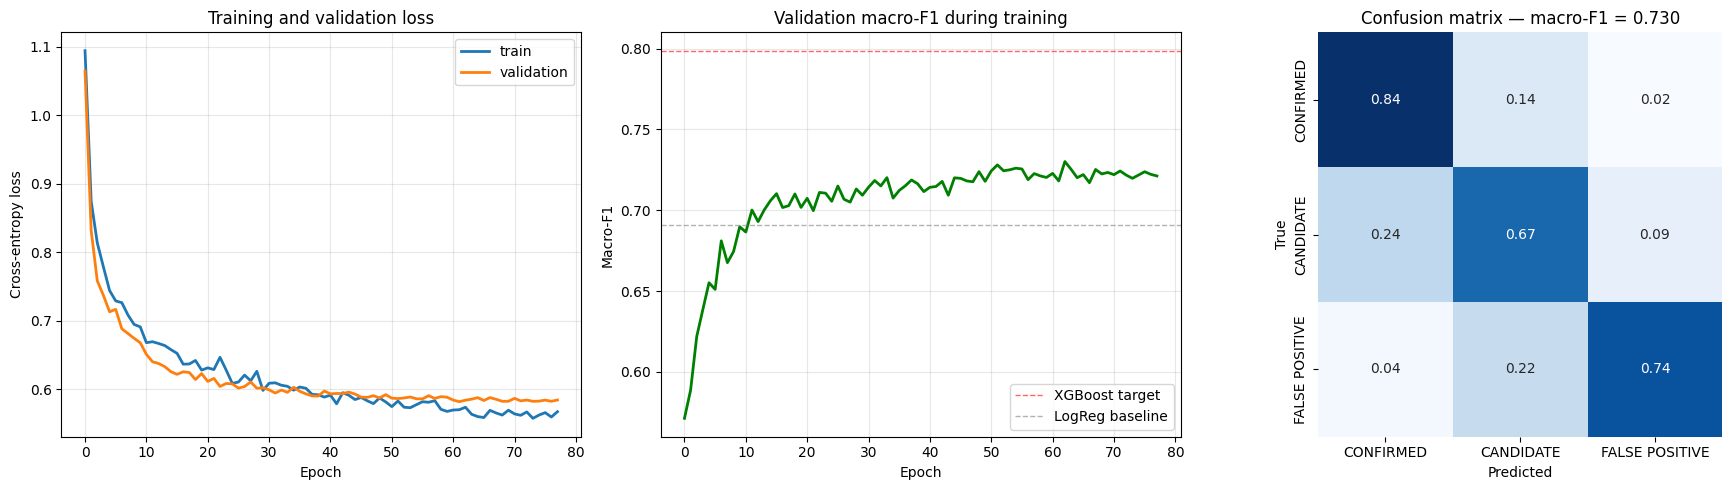

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(mlp_history["train_loss"], label="train", linewidth=2)
axes[0].plot(mlp_history["val_loss"], label="validation", linewidth=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy loss")
axes[0].set_title("Training and validation loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(mlp_history["val_macro_f1"], color="green", linewidth=2)
axes[1].axhline(y=0.7987, color="red", linestyle="--", linewidth=1, alpha=0.6, label="XGBoost target")
axes[1].axhline(y=0.6908, color="gray", linestyle="--", linewidth=1, alpha=0.6, label="LogReg baseline")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Macro-F1")
axes[1].set_title("Validation macro-F1 during training")
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

cm = mlp_val["confusion_matrix"]
cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_order,
    yticklabels=class_order,
    ax=axes[2],
    cbar=False,
    square=True,
)
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("True")
axes[2].set_title(f"Confusion matrix — macro-F1 = {mlp_val['macro_f1']:.3f}")

plt.tight_layout()
plt.show()

### 2.6. MLP results summary

The MLP achieves macro-F1 = **0.730** on the leak-free validation set, positioned between LogReg (0.691) and XGBoost (0.799). Its main improvement over LogReg comes from the `CANDIDATE` class, where recall jumps from 36% to 67% thanks to non-linear feature interactions and class-weighted loss. However, this comes at a cost: `FALSE POSITIVE` recall drops from 90% (XGBoost) to 74%, with 22% of true false positives now misclassified as `CANDIDATE`. This suggests the class weights are somewhat aggressive; the model is willing to trade majority-class accuracy for minority-class recall. Overall, the MLP validates the deep learning approach but does not yet challenge the XGBoost baseline we expect ResNet-Tabular and FT-Transformer to close this gap.

## 3. Residual Tabular Network

The plain MLP suffers from a well-known problem in deep networks: as depth increases, gradients can vanish and layers stop learning effectively. ResNet solved this for computer vision, our second deep learning baseline.

### 3.1. Why residual connections

A standard MLP layer computes `y = f(x)`, where `f` is a non-linear transformation. When many such layers stack, the gradient signal must pass through every non-linearity during backpropagation, which can shrink it exponentially (vanishing gradient). A residual block instead computes `y = f(x) + x`, adding a direct shortcut from input to output. During backpropagation, the gradient can flow through this shortcut unchanged, keeping earlier layers trainable even in deep networks.

### 3.2. Architecture

Our ResNet-Tabular consists of a stack of residual blocks followed by a classification head. Each residual block applies BatchNorm → Linear → GELU → Dropout → Linear, then adds the input back to the output. Since the input and output dimensions of the block are the same, no projection is needed for the skip connection.

In [14]:
class ResidualBlock(nn.Module):
    """A single residual block: BatchNorm → Linear → GELU → Dropout → Linear + skip connection."""

    def __init__(self, dim: int, hidden_dim: int, dropout: float = 0.3):
        super().__init__()
        self.norm = nn.BatchNorm1d(dim)
        self.linear1 = nn.Linear(dim, hidden_dim)
        self.activation = nn.GELU()
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(hidden_dim, dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.norm(x)
        out = self.linear1(out)
        out = self.activation(out)
        out = self.dropout(out)
        out = self.linear2(out)
        return out + x


class ResNetTabular(nn.Module):
    """ResNet-style network for tabular classification.

    Applies an input projection, then a stack of residual blocks, then a classification head.
    """

    def __init__(
        self,
        in_features: int,
        n_classes: int = 3,
        d_model: int = 128,
        hidden_dim: int = 256,
        n_blocks: int = 4,
        dropout: float = 0.3,
    ):
        super().__init__()
        self.input_projection = nn.Linear(in_features, d_model)

        self.blocks = nn.ModuleList([
            ResidualBlock(dim=d_model, hidden_dim=hidden_dim, dropout=dropout)
            for _ in range(n_blocks)
        ])

        self.head = nn.Sequential(
            nn.BatchNorm1d(d_model),
            nn.GELU(),
            nn.Linear(d_model, n_classes),
        )

        self._init_weights()

    def _init_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.kaiming_normal_(module.weight, nonlinearity="relu")
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.input_projection(x)
        for block in self.blocks:
            x = block(x)
        return self.head(x)


resnet = ResNetTabular(in_features=len(features_c))
n_params = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
print(f"ResNetTabular architecture:")
print(f"  Input features: {len(features_c)}")
print(f"  Model dim (d_model): 128")
print(f"  Hidden dim: 256")
print(f"  Number of residual blocks: 4")
print(f"  Trainable parameters: {n_params:,}")

ResNetTabular architecture:
  Input features: 51
  Model dim (d_model): 128
  Hidden dim: 256
  Number of residual blocks: 4
  Trainable parameters: 272,003


### 3.3. Training on leak-free configuration

We train the ResNet-Tabular using the same `train_model` utility, the same class weights, and the same early stopping criterion as the MLP.

In [15]:
torch.manual_seed(RANDOM_SEED)

resnet = ResNetTabular(in_features=len(features_c))

resnet_trained, resnet_history = train_model(
    model=resnet,
    train_loader=train_loader,
    val_loader=val_loader,
    class_weights=class_weights,
)

Epoch   1: train_loss=0.8419  val_loss=0.8626  val_macro_f1=0.6586
Epoch   5: train_loss=0.6160  val_loss=0.6386  val_macro_f1=0.7047
Epoch  10: train_loss=0.5808  val_loss=0.6089  val_macro_f1=0.7271
Epoch  15: train_loss=0.5475  val_loss=0.6073  val_macro_f1=0.7241
Epoch  20: train_loss=0.5246  val_loss=0.5881  val_macro_f1=0.7349
Epoch  25: train_loss=0.5060  val_loss=0.5990  val_macro_f1=0.7363
Epoch  30: train_loss=0.4921  val_loss=0.5931  val_macro_f1=0.7317
Early stopping at epoch 31 (best macro-F1 = 0.7390)


### 3.4. Save model checkpoint

We save the trained ResNet weights and training history so Notebook 04 can load them for interpretability analysis without retraining.

In [16]:
torch.save({
    "model_state_dict": resnet_trained.state_dict(),
    "features": features_c,
    "n_features": len(features_c),
    "config": {
        "d_model": 128,
        "hidden_dim": 256,
        "n_blocks": 4,
        "dropout": 0.3,
    },
}, MODELS_PATH / "resnet_leak_free.pt")

with open(MODELS_PATH / "resnet_leak_free_history.json", "w") as f:
    json.dump(resnet_history, f, indent=2)

print(f"Saved to {MODELS_PATH.resolve()}")
print(f"  resnet_leak_free.pt")
print(f"  resnet_leak_free_history.json")

Saved to /home/atilla/projects/kepler-exoplanet-dl/models/dl
  resnet_leak_free.pt
  resnet_leak_free_history.json


### 3.5. Evaluation and confusion matrix

We evaluate the trained ResNet on validation and visualize training curves, macro-F1 progress, and confusion matrix in a single figure — the same layout used for the MLP for direct visual comparison.

In [17]:
resnet_val = evaluate_model(resnet_trained, val_loader)

print(f"ResNet validation results (leak-free):")
print(f"  Accuracy:       {resnet_val['accuracy']:.4f}")
print(f"  Macro-F1:       {resnet_val['macro_f1']:.4f}")
print(f"  F1 CONFIRMED:   {resnet_val['f1_confirmed']:.4f}")
print(f"  F1 CANDIDATE:   {resnet_val['f1_candidate']:.4f}")
print(f"  F1 FALSE POS:   {resnet_val['f1_false_pos']:.4f}")

ResNet validation results (leak-free):
  Accuracy:       0.7638
  Macro-F1:       0.7390
  F1 CONFIRMED:   0.8183
  F1 CANDIDATE:   0.5661
  F1 FALSE POS:   0.8327


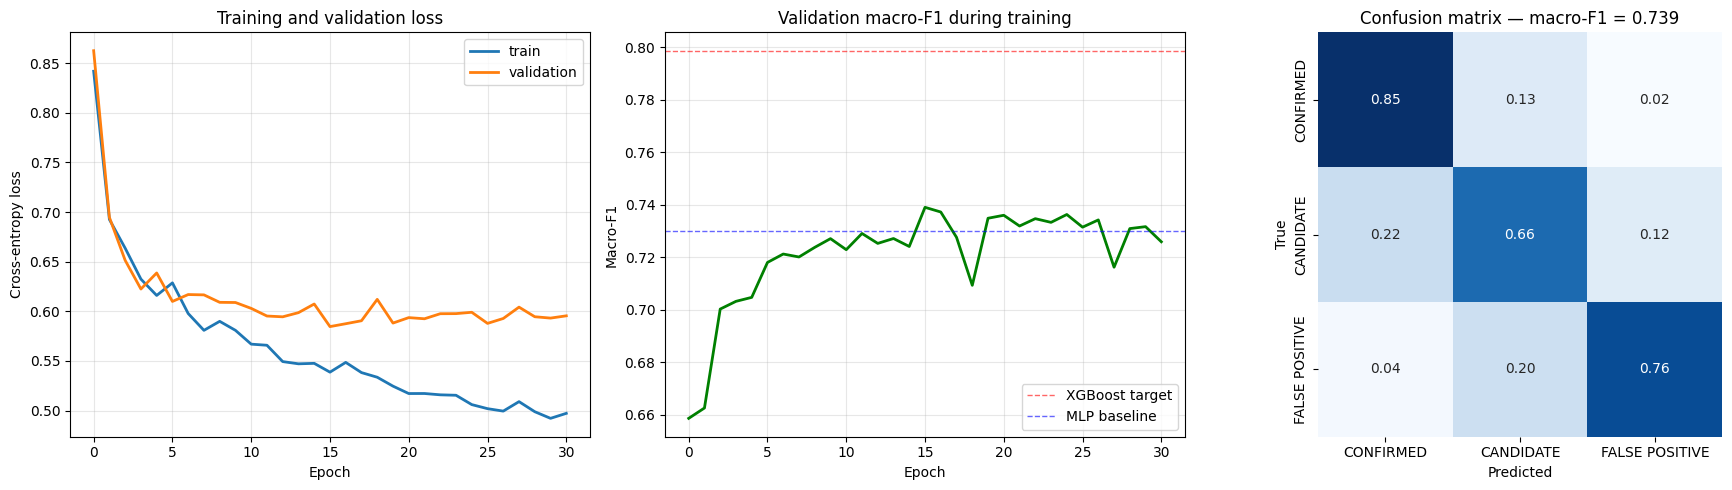

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(resnet_history["train_loss"], label="train", linewidth=2)
axes[0].plot(resnet_history["val_loss"], label="validation", linewidth=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy loss")
axes[0].set_title("Training and validation loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(resnet_history["val_macro_f1"], color="green", linewidth=2)
axes[1].axhline(y=0.7987, color="red", linestyle="--", linewidth=1, alpha=0.6, label="XGBoost target")
axes[1].axhline(y=0.7301, color="blue", linestyle="--", linewidth=1, alpha=0.6, label="MLP baseline")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Macro-F1")
axes[1].set_title("Validation macro-F1 during training")
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

cm = resnet_val["confusion_matrix"]
cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_order,
    yticklabels=class_order,
    ax=axes[2],
    cbar=False,
    square=True,
)
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("True")
axes[2].set_title(f"Confusion matrix — macro-F1 = {resnet_val['macro_f1']:.3f}")

plt.tight_layout()
plt.show()

### 3.6. ResNet results summary

The ResNet-Tabular achieves macro-F1 = **0.739** on the leak-free validation set, a modest 1-point improvement over the plain MLP (0.730). More importantly, the training dynamics are notably cleaner: convergence in ~15 epochs versus ~50 for the MLP, and per-class F1 scores improve uniformly across all three classes rather than trading one class for another. Both effects are consistent with the theoretical benefits of residual connections — more stable gradient flow enables the network to learn a balanced representation.

However, the gap to XGBoost (0.799) remains sizeable at 6 percentage points. Neither the MLP nor ResNet can match the tree-based baseline on this dataset, which is consistent with recent benchmarks (Grinsztajn et al., 2022) showing that gradient-boosted trees remain competitive on small tabular problems.